# Load the data and set the neural network parameters

/!\ Parameters can be changed in this cell, please read the comments. /!\



**The PINEM parameters follow this ordering : g, rt, fwhm, omega, offset**


## Setting the training parameters

In [1]:
# ------------- Relevant paths ---------------------------------
# Paths to the training dataset, the test dataset and the logger
filename = './datasets/pinem_amp100_bkgd0.1_nort_seed42.npz'
test_filename = './datasets/test_model_pinem_amp100_bkgd0.1_nort_seed42.npz'
logger_path = './logs/dnn_kiyohara2019_v2.json'

# Normalization method : 'normalize' or 'scale' or 'both'. None should be avoided
normalization = 'normalize'

# ------------- Network architecture ----------------------------
# Number of parameters to be learned by the network
n_params = 1
# Loss function of the network : 'normal' of 'poisson
mode = 'normal'
# Network layers : list of integers
layers = [768, 512, 512]
# Kernel sizes : list of integers /!\ must have the same length as layers /!\
kernel_sizes = [3, 3, 3]
# Dropout rates : list of floats /!\ must have the same length as layers /!\
dropout_rates = [0.5, 0.5, 0.5]

## Initialisation of the data and network

In [2]:
import mlpynem.models as m
import mlpynem.dataset as d
import numpy as np
import mlpynem.logger as l

# dummy parameters for the loading of the dataset (They don't matter, it just has to be a list of 5 elements)
_ = [None,None,None,None,None]

dataset = d.DatasetPinem(*_,load = filename)
pipe = m.DataPreprocessor(dataset.noisy_spectres, dataset.xs[:,:-(5-n_params)],normalization=normalization, convolution=False)

log = l.ModelInfo(logger_path)
log.add_iteration(filename,test_filename)
log.save_norm(normalization)

(X_train, y_train), (X_val, y_val), (X_test, y_test) = pipe.preprocess()

# cnn = m.CNNModel(dataset.p.x.shape[0],n_params, mode = mode,filters=layers,kernel_size=kernel_sizes,dropouts=dropout_rates)
dnn = m.DNNModel(dataset.p.x.shape[0],n_params, mode = mode,layers=layers,dropouts=dropout_rates)

log.save_model(dnn)


2024-03-22 14:49:00.277149: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-22 14:49:00.414276: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-22 14:49:00.414311: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-22 14:49:00.435208: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-22 14:49:00.476927: I tensorflow/core/platform/cpu_feature_guar

## Train the network and plot the loss

/!\ It might take a while. If you run the code on a laptop it is time to plug it. /!\

In [3]:
dnn.train(X_train, y_train, X_val, y_val, epochs = 300, batch_size = 32)


Epoch 1/300


2024-03-22 14:49:09.958913: I external/local_xla/xla/service/service.cc:168] XLA service 0x7425a1910b60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-03-22 14:49:09.958930: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A3000 Laptop GPU, Compute Capability 8.6
2024-03-22 14:49:09.965393: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-03-22 14:49:09.982058: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
I0000 00:00:1711115350.040536   45874 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1434/1434 [==============================] - 4s 2ms/step - loss: 0.3275 - mse: 0.3275 - mae: 0.4508 - val_loss: 0.1630 - val_mse: 0.1630 - val_mae: 0.3304
Epoch 2/300
1434/1434 [==============================] - 2s 2ms/step - loss: 0.2256 - mse: 0.2256 - mae: 0.3734 - val_loss: 0.1587 - val_mse: 0.1587 - val_mae: 0.3197
Epoch 3/300
1434/1434 [==============================] - 2s 2ms/step - loss: 0.1993 - mse: 0.1993 - mae: 0.3514 - val_loss: 0.1561 - val_mse: 0.1561 - val_mae: 0.3209
Epoch 4/300
1434/1434 [==============================] - 2s 2ms/step - loss: 0.1926 - mse: 0.1926 - mae: 0.3437 - val_loss: 0.1525 - val_mse: 0.1525 - val_mae: 0.3137
Epoch 5/300
1434/1434 [==============================] - 2s 2ms/step - loss: 0.1939 - mse: 0.1939 - mae: 0.3434 - val_loss: 0.1460 - val_mse: 0.1460 - val_mae: 0.3062
Epoch 6/300
1434/1434 [==============================] - 2s 2ms/step - loss: 0.1876 - mse: 0.1876 - mae: 0.3387 - val_loss: 0.1466 - val_mse: 0.1466 - val_mae: 0.3165
Epoch 7/30

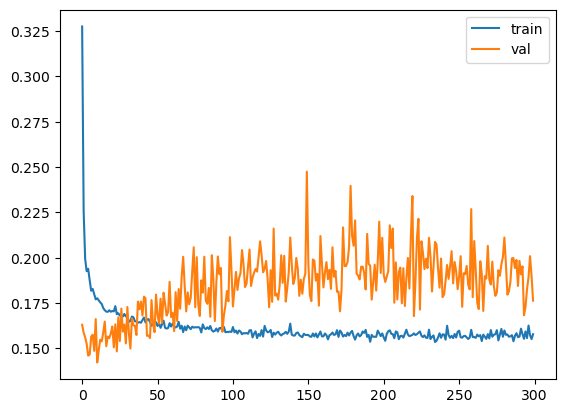

In [4]:
dnn.plot_history()

## Test the network

In [5]:
tst = np.load(test_filename)
test_pipe = m.DataPreprocessor(1,2)
X_test = test_pipe.normalize_data(tst['data'])[:,:,np.newaxis]
res = dnn.predict(X_test)

err = res - tst['truth']
mean_err = np.mean(err, axis = 0)
std_err = np.std(err, axis = 0)
err_dict= {'mean_g_err' : mean_err[0], 'std_g_err' : std_err[0]}

79/79 [==============================] - 0s 652us/step


## Save the results

In [6]:
log.save_test_results(err_dict)
log.save()

In [7]:
dnn.save_model('./models/dnn_kiyohara2019_v2.h5')

/home/adrien/anaconda3/envs/keras2/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [9]:
dnn.predict(np.random.rand(1,1024,1))

1/1 [==============================] - 0s 13ms/step


array([[-2.1363354]], dtype=float32)

In [28]:
a = np.random.rand(1024)
print(a.shape)
a = a[np.newaxis,:,np.newaxis]
print(a.shape)
cnn.predict(a)

(1024,)
(1, 1024, 1)
1/1 [==============================] - 0s 11ms/step


array([[-0.03483346]], dtype=float32)

In [16]:
import keras as k

In [17]:
k.layers.ReLU()

keras.src.layers.activation.relu.ReLU